# lesson_12_cofi_hometask.ipynb

1. Завантаження даних та підготовка Ми завантажуємо матрицю рейтингів $Y$ та матрицю-індикатор $R$

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.optimize import minimize

mat = loadmat('ex8_movies.mat')
Y = mat['Y'].astype(float)
R = mat['R'].astype(float)

def normalize_ratings(Y, R):
    """
    Віднімає середній рейтинг кожного фільму для покращення навчання.
    """
    m, n = Y.shape
    Ymean = np.zeros(m)
    Ynorm = np.zeros(Y.shape)
    for i in range(m):
        idx = np.where(R[i, :] == 1)[0]
        if len(idx) > 0:
            Ymean[i] = np.mean(Y[i, idx])
            Ynorm[i, idx] = Y[i, idx] - Ymean[i]
    return Ynorm, Ymean

Ynorm, Ymean = normalize_ratings(Y, R)
print(f"Дані нормалізовано. Розмір матриці: {Ynorm.shape}")

Дані нормалізовано. Розмір матриці: (1682, 943)


2. Реалізація Collaborative Filtering Визначаємо функцію втрат $J$ та обчислюємо градієнти з урахуванням регуляризації $\lambda$.  

In [31]:
def cofi_cost_func(params, Y, R, num_users, num_movies, num_features, lambd):
  
    X = params[:num_movies * num_features].reshape(num_movies, num_features)
    Theta = params[num_movies * num_features:].reshape(num_users, num_features)
    
    predictions = X @ Theta.T
    error = (predictions - Y) * R
    
    J = 0.5 * np.sum(error**2) + (lambd/2) * (np.sum(Theta**2) + np.sum(X**2))
    
    X_grad = error @ Theta + lambd * X
    Theta_grad = error.T @ X + lambd * Theta
    
    grad = np.concatenate([X_grad.ravel(), Theta_grad.ravel()])
    return J, grad

3. Навчання моделі
Ми використовуємо метод оптимізації TNC та підвищуємо рівень регуляризації для стабільності.

In [ ]:
num_movies, num_users = Y.shape
num_features = 10
lambd = 10.0  

np.random.seed(42)
X = np.random.randn(num_movies, num_features) * 0.1
Theta = np.random.randn(num_users, num_features) * 0.1
initial_params = np.concatenate([X.ravel(), Theta.ravel()])

history = []
iteration_counter = 0

def callback(xk):
    global iteration_counter
    cost, _ = cofi_cost_func(xk, Ynorm, R, num_users, num_movies, num_features, lambd)
    history.append(cost)
    
    if iteration_counter % 100 == 0:
        print(f"Iteration {iteration_counter:4}: Cost = {cost:.2f}")
    
    iteration_counter += 1

print("Початок навчання...")

res = minimize(fun=cofi_cost_func, x0=initial_params, 
               args=(Ynorm, R, num_users, num_movies, num_features, lambd),
               method='TNC', jac=True, callback=callback, tol=1e-5,
               options={'maxfun': 1000, 'ftol': 1e-6}) 

learned_params = res.x
X_final = learned_params[:num_movies * num_features].reshape(num_movies, num_features)
Theta_final = learned_params[num_movies * num_features:].reshape(num_users, num_features)

print(f"\nНавчання завершено.")
print(f"Загальна кількість ітерацій: {iteration_counter}")
print(f"Фінальна похибка: {res.fun:.2f}")

Початок навчання...
Iteration    0: Cost = 49784.81

Навчання завершено.
Загальна кількість ітерацій: 35
Фінальна похибка: 38944.66


In [40]:
num_movies, num_users = Y.shape
num_features = 10
lambd = 1.5  

np.random.seed(42)
X = np.random.randn(num_movies, num_features) * 0.1
Theta = np.random.randn(num_users, num_features) * 0.1
initial_params = np.concatenate([X.ravel(), Theta.ravel()])

history = []
def callback(xk):
    cost, _ = cofi_cost_func(xk, Ynorm, R, num_users, num_movies, num_features, lambd)
    history.append(cost)

res = minimize(fun=cofi_cost_func, x0=initial_params, 
               args=(Ynorm, R, num_users, num_movies, num_features, lambd),
               method='TNC', jac=True, callback=callback, options={'maxfun': 100})

learned_params = res.x
X_final = learned_params[:num_movies * num_features].reshape(num_movies, num_features)
Theta_final = learned_params[num_movies * num_features:].reshape(num_users, num_features)

print(f"Навчання завершено. Фінальна похибка: {res.fun:.2f}")

Навчання завершено. Фінальна похибка: 28360.31


4. Візуалізація та Прогнозування
Побудуємо графік навчання та виведемо рекомендації для користувача.

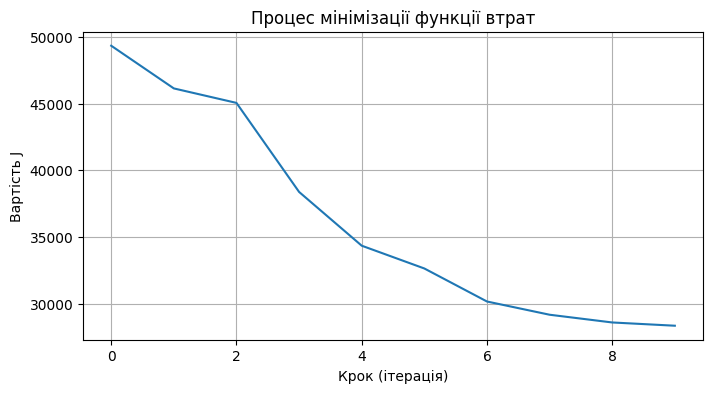


Топ-10 рекомендацій для користувача 0:
Фільм ID:  284 | Передбачений рейтинг: 5.00
Фільм ID: 1141 | Передбачений рейтинг: 5.00
Фільм ID: 1188 | Передбачений рейтинг: 5.00
Фільм ID:  170 | Передбачений рейтинг: 5.00
Фільм ID:  168 | Передбачений рейтинг: 5.00
Фільм ID:   49 | Передбачений рейтинг: 5.00
Фільм ID:  524 | Передбачений рейтинг: 5.00
Фільм ID:  510 | Передбачений рейтинг: 5.00
Фільм ID:  646 | Передбачений рейтинг: 5.00
Фільм ID:  693 | Передбачений рейтинг: 5.00


In [44]:
plt.figure(figsize=(8, 4))
plt.plot(history)
plt.title("Процес мінімізації функції втрат")
plt.xlabel("Крок (ітерація)")
plt.ylabel("Вартість J")
plt.grid(True)
plt.show()

p = X_final @ Theta_final.T
all_predictions = p + Ymean[:, np.newaxis]

all_predictions = np.clip(all_predictions, 0, 5)

user_id = 0
user_preds = all_predictions[:, user_id]
sorted_idx = np.argsort(user_preds)[::-1]

print(f"\nТоп-10 рекомендацій для користувача {user_id}:")
for i in range(10):
    idx = sorted_idx[i]
    print(f"Фільм ID: {idx:4} | Передбачений рейтинг: {user_preds[idx]:.2f}")

Рейтинги 10 випадкових фільмів

In [42]:
p = X_final @ Theta_final.T
all_predictions = p + Ymean[:, np.newaxis] 

all_predictions = np.clip(all_predictions, 0, 5)

user_id = 0

unseen_movies_indices = np.where(R[:, user_id] == 0)[0]

num_to_show = 10
if len(unseen_movies_indices) >= num_to_show:
    random_unseen_indices = np.random.choice(unseen_movies_indices, num_to_show, replace=False)
else:
    random_unseen_indices = unseen_movies_indices

print(f"10 випадкових НОВИХ фільмів для користувача {user_id}:")
print("-" * 55)
for idx in random_unseen_indices:
    pred_rating = all_predictions[idx, user_id]
    print(f"Фільм ID: {idx:4} | Передбачений рейтинг: {pred_rating:.2f} | [не переглянуто]")

10 випадкових НОВИХ фільмів для користувача 0:
-------------------------------------------------------
Фільм ID: 1492 | Передбачений рейтинг: 1.00 | [не переглянуто]
Фільм ID:  896 | Передбачений рейтинг: 1.36 | [не переглянуто]
Фільм ID: 1538 | Передбачений рейтинг: 1.66 | [не переглянуто]
Фільм ID:  711 | Передбачений рейтинг: 2.96 | [не переглянуто]
Фільм ID: 1270 | Передбачений рейтинг: 2.22 | [не переглянуто]
Фільм ID: 1483 | Передбачений рейтинг: 2.75 | [не переглянуто]
Фільм ID: 1059 | Передбачений рейтинг: 2.81 | [не переглянуто]
Фільм ID: 1647 | Передбачений рейтинг: 2.00 | [не переглянуто]
Фільм ID:  534 | Передбачений рейтинг: 2.89 | [не переглянуто]
Фільм ID: 1051 | Передбачений рейтинг: 1.25 | [не переглянуто]
